# Red Neuronal Multicapa (MLP) con PyTorch

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA**
* **Nomenclatura Oficial:** Procesamiento de Lenguaje Natural
* **Nombre de Trabajo:** Laboratorio de PLN: Analítica, Textos y Cultura

---

## Objetivo
Introducir la biblioteca PyTorch construyendo una red neuronal multicapa (MLP) para clasificar texto representado vectorialmente.

## Resultados de aprendizaje
Al final de este notebook vas a poder:
1. Declarar tensores y construir arquitecturas multicapa modulares con PyTorch.
2. Comprender los pasos del bucle de entrenamiento (forward pass, pérdida, backpropagation y optimización).
3. Diseñar arquitecturas neuronales multicapa para resolver problemas no lineales de clasificación.



## Terminología clave (Microglosario)

* **✦ Tensor:** Estructura de datos fundamental de PyTorch similar a los arreglos de NumPy pero optimizada para computación paralela en GPU y diferenciación automática.
* **✦ Perceptrón Multicapa (MLP):** Red neuronal feedforward compuesta de una capa de entrada, una o más capas ocultas y una capa de salida con conexiones completas (fully connected).
* **✦ Retropropagación (Backpropagation):** Algoritmo que calcula el gradiente del error de la red respecto a sus parámetros utilizando la regla de la cadena matemática, permitiendo ajustar los pesos.



## 1. Importación de Librerías
Cargamos PyTorch, Scikit-learn para preparar los datos y Matplotlib para graficar.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Configuramos semillas para que todo sea reproducible
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Versión: {torch.__version__}")


PyTorch Versión: 2.12.0+cpu


---
## 2. El Dataset Didáctico
Usaremos 20 reseñas de comida en español rioplatense para entrenar nuestra red.


In [2]:
frases = [
    "La verdad, este lugar está bárbaro. Muy recomendable.",
    "Qué buena onda la atención, volvería sin dudarlo.",
    "Me encantó la comida, aunque la música estaba muy fuerte.",
    "Todo excelente. Atención de diez.",
    "Muy conforme con el resultado final.",
    "Superó mis expectativas, gracias.",
    "El mejor asado que probé en mucho tiempo.",
    "Excelente relación precio-calidad, muy recomendable.",
    "La atención fue impecable, muy atentos.",
    "Me gustó mucho el ambiente tranquilo.",
    "Una porquería de servicio, nunca más vuelvo.",
    "El envío fue lento y el producto llegó dañado. Qué desastre.",
    "Qué estafa, me arrepiento de haber comprado.",
    "No me gustó para nada la experiencia.",
    "No lo recomiendo, mala calidad.",
    "Malísima atención, el mozo tenía mala onda.",
    "Tardaron dos horas en entregar, llegó todo frío.",
    "Me cobraron de más y encima se hicieron los giles.",
    "La carne estaba pasada, casi no se podía comer.",
    "Pésima experiencia, no vuelvo más."
]

# Etiquetas: 10 positivas (1) y 10 negativas (0)
etiquetas = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


---
## 3. Vectorización Didáctica (¡Conectando con Scikit-learn!)

**Nota metodológica:** En lugar de crear un vectorizador complejo a mano, usaremos `CountVectorizer` de Scikit-learn que ya dominamos. Así preparamos los datos de forma rápida y nos enfocamos 100% en las redes neuronales de PyTorch.


In [3]:
# 1. Instanciamos el vectorizador limitando a las 25 palabras más frecuentes
vectorizador = CountVectorizer(max_features=25)

# 2. 'fit' aprende las palabras clave del corpus
vectorizador.fit(frases)

# 3. 'transform' convierte el texto crudo en una matriz de números
matriz_frecuencias = vectorizador.transform(frases).toarray()

print("Vocabulario de 25 palabras aprendido:")
print(vectorizador.get_feature_names_out())


Vocabulario de 25 palabras aprendido:
['atención' 'bárbaro' 'calidad' 'de' 'el' 'en' 'estaba' 'excelente'
 'experiencia' 'fue' 'gustó' 'la' 'llegó' 'mala' 'me' 'mucho' 'muy' 'más'
 'no' 'onda' 'qué' 'recomendable' 'se' 'todo' 'vuelvo']


### Conversión a Tensores de PyTorch
Las redes neuronales de PyTorch no entienden arrays de NumPy; necesitan **Tensores** (la estructura nativa que permite cálculos ultrarrápidos).


In [4]:
# Convertimos los datos a tensores con precisión float32
X = torch.tensor(matriz_frecuencias, dtype=torch.float32)
y = torch.tensor(etiquetas, dtype=torch.float32).reshape(-1, 1)

print("Forma del tensor X (Muestras x Palabras):", X.shape)
print("Forma del tensor y (Etiquetas):          ", y.shape)


Forma del tensor X (Muestras x Palabras): torch.Size([20, 25])
Forma del tensor y (Etiquetas):           torch.Size([20, 1])


---
## 4. Definiendo la Red Multicapa (MLP) en PyTorch

Creamos nuestra red heredando de `nn.Module`. Definiremos cada capa de forma explícita para entender el recorrido interno de los datos.


In [5]:
class RedMulticapa(nn.Module):
    def __init__(self, tamaño_entrada, tamaño_oculto):
        super().__init__()
        
        # Capa 1: Entrada -> Capa Oculta (conecta las 25 palabras con 8 neuronas)
        self.capa_oculta = nn.Linear(tamaño_entrada, tamaño_oculto)
        
        # Función de activación ReLU (El interruptor inteligente)
        self.activacion_relu = nn.ReLU()
        
        # Capa 2: Capa Oculta -> Salida (conecta las 8 neuronas a 1 decisión)
        self.capa_salida = nn.Linear(tamaño_oculto, 1)
        
        # Función de activación Sigmoid (La fábrica de probabilidades)
        self.activacion_sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Definimos el recorrido de los datos por la red
        z1 = self.capa_oculta(x)
        a1 = self.activacion_relu(z1)
        z2 = self.capa_salida(a1)
        probabilidad = self.activacion_sigmoid(z2)
        return probabilidad

# Instanciamos la red: 25 entradas (vocabulario) -> 8 neuronas ocultas -> 1 salida
modelo = RedMulticapa(tamaño_entrada=25, tamaño_oculto=8)
print(modelo)


RedMulticapa(
  (capa_oculta): Linear(in_features=25, out_features=8, bias=True)
  (activacion_relu): ReLU()
  (capa_salida): Linear(in_features=8, out_features=1, bias=True)
  (activacion_sigmoid): Sigmoid()
)


---
## 5. Función de Pérdida y Optimizador
- **BCELoss (Binary Cross Entropy):** Mide el error del modelo calculando qué tan lejos están las probabilidades predichas de las etiquetas reales (0 o 1).
- **Adam (Optimizador):** Nuestro guía dinámico que actualizará los pesos de la red paso a paso.


In [6]:
criterio_perdida = nn.BCELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.01)

print("Función de Pérdida y Optimizador configurados correctamente.")


Función de Pérdida y Optimizador configurados correctamente.


---
## 6. El Bucle de Entrenamiento (Ciclo PyTorch)

El ciclo estándar de entrenamiento de toda red en PyTorch consta de 4 pasos repetitivos por cada época:
1. **Forward:** Calcular predicciones con el estado actual de la red.
2. **Loss:** Medir el error cometido.
3. **Zero Grad:** Limpiar los gradientes del paso anterior.
4. **Backward & Step:** Calcular la dirección del error (backpropagation) y ajustar los pesos (paso del optimizador).


In [7]:
epocas = 150
historial_perdida = []

modelo.train() # Ponemos el modelo en modo entrenamiento

for epoca in range(epocas):
    # 1. Forward: Calculamos predicciones
    predicciones = modelo(X)
    
    # 2. Loss: Calculamos la pérdida
    perdida = criterio_perdida(predicciones, y)
    
    # 3. Zero Grad: Limpiamos los gradientes anteriores
    optimizador.zero_grad()
    
    # 4. Backward & Step: Propagamos el error y ajustamos pesos
    perdida.backward()
    optimizador.step()
    
    # Guardamos el progreso
    historial_perdida.append(perdida.item())
    
    # Mostramos progreso cada 15 épocas
    if (epoca + 1) % 15 == 0:
        print(f"Época {epoca+1:3d}/{epocas} -> Pérdida (Loss): {perdida.item():.4f}")


Época  15/150 -> Pérdida (Loss): 0.5776
Época  30/150 -> Pérdida (Loss): 0.3386
Época  45/150 -> Pérdida (Loss): 0.1484
Época  60/150 -> Pérdida (Loss): 0.0681
Época  75/150 -> Pérdida (Loss): 0.0361
Época  90/150 -> Pérdida (Loss): 0.0219
Época 105/150 -> Pérdida (Loss): 0.0149
Época 120/150 -> Pérdida (Loss): 0.0110
Época 135/150 -> Pérdida (Loss): 0.0085
Época 150/150 -> Pérdida (Loss): 0.0069


### Curva de Pérdida (Convergencia)
Graficamos la evolución de la pérdida para comprobar que el modelo está aprendiendo de forma saludable.


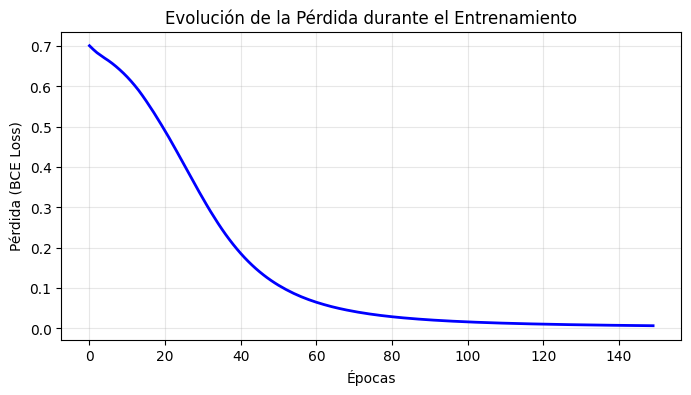

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(historial_perdida, color='blue', linewidth=2)
plt.xlabel("Épocas")
plt.ylabel("Pérdida (BCE Loss)")
plt.title("Evolución de la Pérdida durante el Entrenamiento")
plt.grid(True, alpha=0.3)
plt.show()


---
## 7. Predicciones con Frases Nuevas
Probamos nuestra red entrenada con reseñas nuevas que nunca vio.


In [9]:
frases_nuevas = [
    "Excelente atención y comida impecable.",
    "Una porquería de experiencia, tardaron una eternidad."
]

# 1. Vectorizamos usando el CountVectorizer entrenado
nuevos_vectores = vectorizador.transform(frases_nuevas).toarray()

# 2. Convertimos a tensor de PyTorch
X_nuevos = torch.tensor(nuevos_vectores, dtype=torch.float32)

# 3. Cambiamos a modo evaluación y hacemos la predicción
modelo.eval()
with torch.no_grad(): # Desactivamos autograd para ahorrar memoria
    probabilidades = modelo(X_nuevos)

for i, frase in enumerate(frases_nuevas):
    prob = probabilidades[i].item() * 100
    sentido = "POSITIVO" if prob >= 50 else "NEGATIVO"
    print(f"\nFrase: '{frase}'")
    print(f"Predicción: {sentido} | Probabilidad de ser Positivo: {prob:.1f}%")



Frase: 'Excelente atención y comida impecable.'
Predicción: POSITIVO | Probabilidad de ser Positivo: 99.9%

Frase: 'Una porquería de experiencia, tardaron una eternidad.'
Predicción: NEGATIVO | Probabilidad de ser Positivo: 2.1%


## Consigna de Lectura e Interpretación
**Pregunta para pensar:** Mira las predicciones de las frases nuevas. ¿Qué rol juegan las funciones de activación como ReLU y Sigmoid para que este modelo pueda expresar una probabilidad en porcentaje en lugar de solo responder con un 0 o un 1 absoluto como hacía el Perceptrón del cuaderno anterior?
